First we will import the necessary datasets and libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from ml_from_scratch.supervised.K_nearest_neighbors import KNN

We will now import the iris dataset in order to test the algorithm. Note that while this model does not learn, we will still split it into training and testing data because it will store the training data and thus for a point in the training data, one of its nearest neighbors will be itself.

In [2]:
from sklearn.model_selection import train_test_split

# Load the full Iris dataset

data = load_iris()
X = data.data        
y = data.target


# Splitting into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

We will only look at petal length and width for the purpose of demonstration as it is easier to vizualise with only two features.

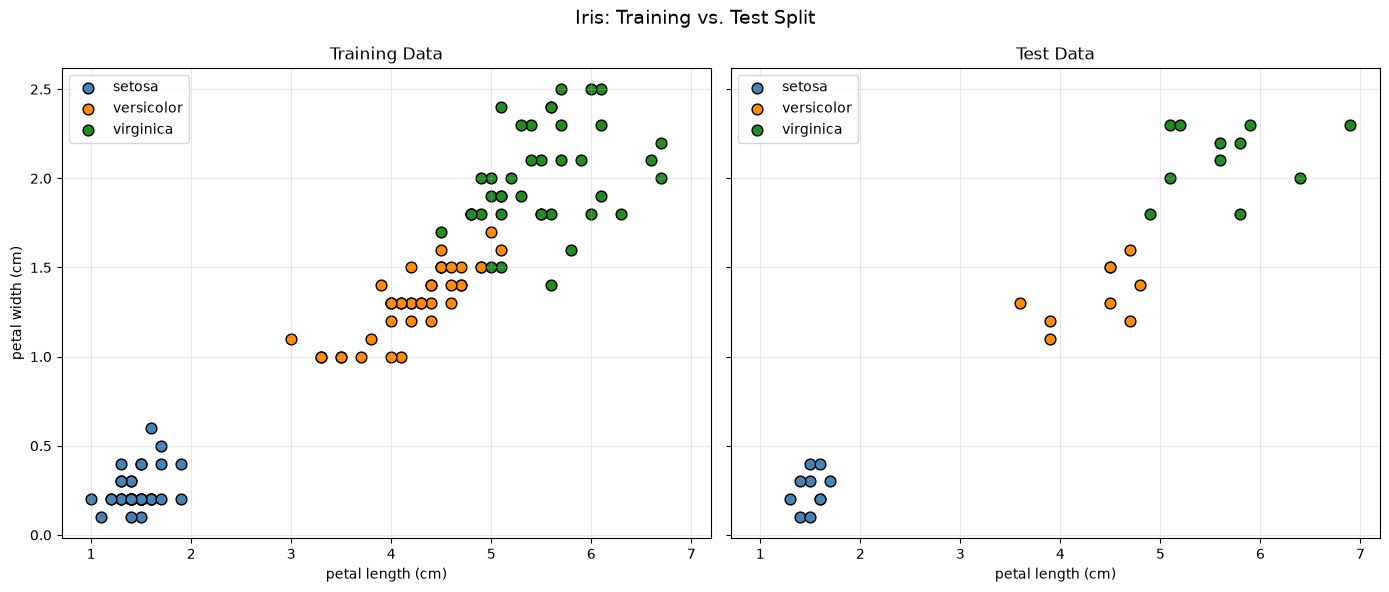

In [4]:
# Picks features to be petal length and width

f1, f2 = 2, 3   

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

colors = ['steelblue', 'darkorange', 'forestgreen']
class_names = data.target_names  

# Training data
for cls in range(3):
    mask = y_train == cls
    axes[0].scatter(X_train[mask, f1], X_train[mask, f2],
                    color=colors[cls], label=class_names[cls],
                    edgecolor='k', s=60)
axes[0].set_title('Training Data')
axes[0].set_xlabel(data.feature_names[f1])
axes[0].set_ylabel(data.feature_names[f2])
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test data
for cls in range(3):
    mask = y_test == cls
    axes[1].scatter(X_test[mask, f1], X_test[mask, f2],
                    color=colors[cls], label=class_names[cls],
                    edgecolor='k', s=60)
axes[1].set_title('Test Data')
axes[1].set_xlabel(data.feature_names[f1])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Iris: Training vs. Test Split', fontsize=14)
plt.tight_layout()
plt.show()

We will now build our KNN on the training data and attempt to predict the testing data. We will choose k=5 to hopefully have a large enough k to predict accurately without having such large k that it bleeds into other classes

In [5]:

# Builds the KNN model with k=5 storing the training data

model = KNN(k=5)
model.store_data(X_train, y_train)

# Predicts the testing data

test_preds = np.array([model.predict(x) for x in X_test])

I will now graph the test data versus the test predictions and print the accuracy below the graphs

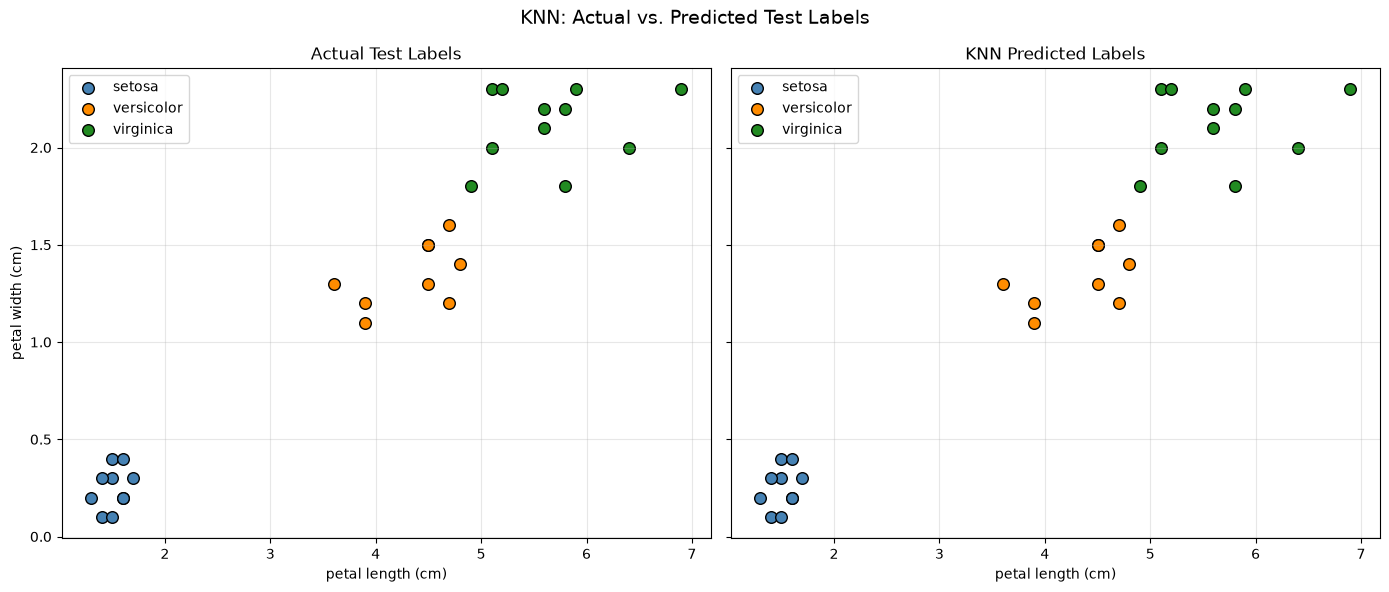

Test Accuracy: 1.0000


In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

colors = ['steelblue', 'darkorange', 'forestgreen']
class_names = data.target_names

# Real labels

for cls in range(3):
    mask = y_test == cls
    axes[0].scatter(X_test[mask, f1], X_test[mask, f2],
                    color=colors[cls], label=class_names[cls],
                    edgecolor='k', s=70)
axes[0].set_title('Actual Test Labels')
axes[0].set_xlabel(data.feature_names[f1])
axes[0].set_ylabel(data.feature_names[f2])
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Predictions

for cls in range(3):
    mask = test_preds == cls
    axes[1].scatter(X_test[mask, f1], X_test[mask, f2],
                    color=colors[cls], label=class_names[cls],
                    edgecolor='k', s=70)
axes[1].set_title('KNN Predicted Labels')
axes[1].set_xlabel(data.feature_names[f1])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('KNN: Actual vs. Predicted Test Labels', fontsize=14)
plt.tight_layout()
plt.show()


# Printed accuracy below the plots

accuracy = np.mean(test_preds == y_test)
print(f"Test Accuracy: {accuracy:.4f}")

As shown, KNN achieves 100% accuracy on this dataset. Because the data is separated into pretty separate clumps and is also pretty small, it makes sense that this method would have a high accuracy rate. Note that the accuracy will likely drop if we test on the entire dataset which I will do below

In [ ]:

#  Predict on the full dataset

all_preds = np.array([model.predict(x) for x in X])

full_accuracy = np.mean(all_preds == y)
print(f"Accuracy on full dataset: {full_accuracy:.4f}")

Accuracy on full dataset: 0.9733


The accuracy only dropped a little but this is mainly because the density of points increased, increasing the chance of more overlap. KNN can really only learn separated clumps in space which while it is so simple, is one of its downfalls. Note also that each of the training data points has itself as a neighbor so this accuracy rating is inflated.